<a href="https://colab.research.google.com/github/smshozab/AG-AquaSense/blob/main/AAIn3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

This notebook implements the **text-based disease classification module** using FastText.

### What this notebook does
- Generates synthetic farmer-style symptom descriptions
  - Includes noise: typos, repetition, informal language
- Trains FastText classifier using character n-grams
- Predicts disease probabilities:

  P_text → probability distribution over 7 classes

### Key outputs
- Model performance:
  - Accuracy, Macro F1
- Confusion matrix and classification report
- Predictions file: `p_text_predictions.csv`

### Usage
- Output probabilities are used in Notebook 5 (fusion)

### Note
- Uses synthetic data to simulate real farmer input

In [ ]:
!pip install numpy==1.26.4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653907 sha256=18507e138ebc938cb6243561035ecfb052fd129fc996338532ab849e9bf8640a
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
import os
import re
import random
import string
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

import fasttext

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path("/content/drive/MyDrive/aquasense/notebook3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DISEASE_CLASSES = [
    "Bacterial Red Disease",
    "Aeromoniasis",
    "Bacterial Gill Disease",
    "Saprolegniasis",
    "Healthy Fish",
    "Parasitic Diseases",
    "White Tail Disease"
]

LABEL_TO_FASTTEXT = {
    "Bacterial Red Disease": "__label__Bacterial_Red_Disease",
    "Aeromoniasis": "__label__Aeromoniasis",
    "Bacterial Gill Disease": "__label__Bacterial_Gill_Disease",
    "Saprolegniasis": "__label__Saprolegniasis",
    "Healthy Fish": "__label__Healthy_Fish",
    "Parasitic Diseases": "__label__Parasitic_Diseases",
    "White Tail Disease": "__label__White_Tail_Disease"
}

FASTTEXT_TO_LABEL = {v: k for k, v in LABEL_TO_FASTTEXT.items()}

SAMPLES_PER_CLASS = 500
TEST_SIZE = 0.2
VAL_SIZE = 0.1

In [ ]:
SYMPTOM_TEMPLATES = {
    "Bacterial Red Disease": [
        "fish has red patches on body",
        "there are red spots near fins",
        "body looks reddish and inflamed",
        "red sores visible on skin",
        "fish skin has bleeding marks",
        "ulcers and red lesions on body",
        "redness around tail and belly",
        "fish body has hemorrhagic spots",
        "skin looks damaged and red",
        "red infected looking patches"
    ],
    "Aeromoniasis": [
        "fish is weak and has ulcers",
        "swollen belly with skin lesions",
        "fish not eating and looks infected",
        "ulcers on body and lethargic movement",
        "fish has rotten looking sores",
        "body infection with weak swimming",
        "fish is dull and has red ulcer",
        "open wound and tired fish",
        "fish floating slowly and not feeding",
        "infection signs and fin damage"
    ],
    "Bacterial Gill Disease": [
        "gills look pale and fish gasping",
        "fish breathing fast near surface",
        "gills seem damaged and swollen",
        "rapid breathing and gill problem",
        "fish opening mouth often and struggling",
        "staying near top and low breathing comfort",
        "gill area looks infected",
        "fish gasping and gills not normal",
        "breathing issue with gill irritation",
        "surface breathing and weak gills"
    ],
    "Saprolegniasis": [
        "cotton like growth on skin",
        "white fungus on body",
        "fuzzy patches on fish skin",
        "fish has wool like infection",
        "white fluffy growth near fins",
        "fungal patch on tail and body",
        "skin has cotton texture",
        "white mold type growth visible",
        "fish body covered with fungal mass",
        "cottony lesions on skin"
    ],
    "Healthy Fish": [
        "fish looks normal and active",
        "no visible disease signs",
        "healthy swimming and feeding well",
        "clear skin and normal fins",
        "fish is active and eating properly",
        "body color normal and movement fine",
        "healthy fish with no symptoms",
        "normal appearance and behavior",
        "no spots or wounds visible",
        "fish seems okay"
    ],
    "Parasitic Diseases": [
        "fish rubbing against tank wall",
        "scratching body and flashing movement",
        "small spots and irritation visible",
        "fish looks restless and rubbing",
        "skin irritation and abnormal movement",
        "parasite like spots on body",
        "itching behavior and flashing",
        "fish is agitated and rubbing body",
        "external irritation and tiny marks",
        "body has parasite type signs"
    ],
    "White Tail Disease": [
        "tail looks white and damaged",
        "white tail region visible",
        "tail muscle looks pale",
        "fish tail has whitish discoloration",
        "white patch near tail area",
        "tail is losing color and getting weak",
        "white faded tail and poor swimming",
        "tail section looks sick and pale",
        "fish has white tail sign",
        "tail end is abnormal and whitish"
    ]
}

In [ ]:
COMMON_TYPOS = {
    "fish": ["fsh", "fis", "fissh"],
    "red": ["reed", "rd"],
    "white": ["wite", "whte"],
    "tail": ["tal", "taill"],
    "gills": ["gils", "gillz"],
    "breathing": ["brething", "breething"],
    "cotton": ["cotten", "coton"],
    "body": ["bdy", "boody"],
    "spots": ["spotes", "spts"],
    "skin": ["skn", "skiin"],
    "swimming": ["swiming", "swmng"],
    "normal": ["nrmal", "normall"],
    "active": ["activ", "actve"],
    "fungus": ["funges", "fungs"],
    "parasite": ["parasit", "parsite"],
    "eating": ["eatin", "eting"],
    "weak": ["wek", "weakk"],
    "surface": ["surfase", "surfece"],
    "infection": ["infction", "infecton"]
}

FILLER_PREFIXES = [
    "pls help",
    "what disease is this",
    "my fish has problem",
    "can you check",
    "need urgent help",
    "sir fish problem",
    "please advise",
    "not sure what this is",
    "fish looking bad",
    ""
]

FILLER_SUFFIXES = [
    "since morning",
    "from yesterday",
    "in one tank only",
    "many fish affected",
    "one fish only",
    "not eating too",
    "water looked okay before",
    "suddenly happened",
    "pls suggest treatment",
    ""
]

CONNECTORS = ["and", "also", "with", "plus", "then", ""]

In [ ]:
def random_typo(word):
    lower = word.lower()
    if lower in COMMON_TYPOS and random.random() < 0.35:
        replacement = random.choice(COMMON_TYPOS[lower])
        if word[0].isupper():
            replacement = replacement.capitalize()
        return replacement
    return word


def random_case_noise(text):
    if random.random() < 0.15:
        return text.upper()
    if random.random() < 0.15:
        return text.lower()
    return text


def random_punctuation_noise(text):
    puncts = ["", ".", "..", "...", "!", "!!", "???"]
    return text + random.choice(puncts)


def random_word_drop(words, drop_prob=0.08):
    kept = []
    for w in words:
        if random.random() > drop_prob or len(words) <= 4:
            kept.append(w)
    return kept if kept else words


def random_duplicate_word(words, dup_prob=0.06):
    out = []
    for w in words:
        out.append(w)
        if random.random() < dup_prob:
            out.append(w)
    return out


def inject_spelling_noise(text):
    words = text.split()
    words = [random_typo(w) for w in words]
    words = random_word_drop(words)
    words = random_duplicate_word(words)
    return " ".join(words)


def create_augmented_symptom_text(base_text):
    prefix = random.choice(FILLER_PREFIXES).strip()
    suffix = random.choice(FILLER_SUFFIXES).strip()

    extra_phrase_pool = [
        "fish not eating",
        "swimming slow",
        "looks weak",
        "seems stressed",
        "few fish affected",
        "one side issue",
        "problem increasing",
        "not moving normal",
        "surface swimming",
        "body color changed",
        ""
    ]

    parts = []
    if prefix:
        parts.append(prefix)

    parts.append(base_text)

    if random.random() < 0.55:
        connector = random.choice(CONNECTORS).strip()
        extra = random.choice(extra_phrase_pool).strip()
        if extra:
            if connector:
                parts.append(connector)
            parts.append(extra)

    if suffix:
        parts.append(suffix)

    text = " ".join([p for p in parts if p]).strip()
    text = inject_spelling_noise(text)
    text = random_case_noise(text)
    text = random_punctuation_noise(text)
    return text

In [ ]:
rows = []

for label in DISEASE_CLASSES:
    templates = SYMPTOM_TEMPLATES[label]
    for _ in range(SAMPLES_PER_CLASS):
        base_text = random.choice(templates)
        text = create_augmented_symptom_text(base_text)
        rows.append({
            "text": text,
            "label": label
        })

text_df = pd.DataFrame(rows)
print("Dataset shape:", text_df.shape)
display(text_df.head(20))

Dataset shape: (3500, 2)


,text,label
0,pls help are red spots near fins also slow one...,Bacterial Red Disease
1,ulcers and reed lesions on body many fish affe...,Bacterial Red Disease
2,can you check fish fish has rd patches on bood...,Bacterial Red Disease
3,WHAT DISEASE IS THIS THIS FISH HAS HAS RD PATC...,Bacterial Red Disease
4,FISSH LOOKING BAD THERE ARE RED FINS PLUS SWIM...,Bacterial Red Disease
5,sir fish problem redness around tail and belly...,Bacterial Red Disease
6,not sure what this is skin looks damaged and r...,Bacterial Red Disease
7,need urgent help skin looks damaged and red!!,Bacterial Red Disease
8,need urgent help help redness around tail and ...,Bacterial Red Disease
9,redness around tal belly in one tank only???,Bacterial Red Disease


,count
label,
Aeromoniasis,500
Bacterial Gill Disease,500
Bacterial Red Disease,500
Healthy Fish,500
Parasitic Diseases,500
Saprolegniasis,500
White Tail Disease,500


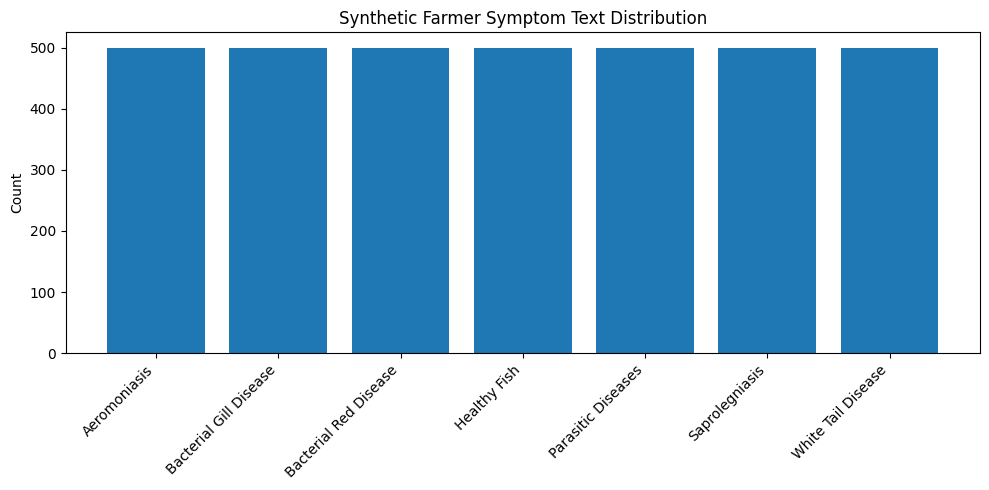

In [ ]:
label_counts = text_df["label"].value_counts().sort_index()
display(label_counts)

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Synthetic Farmer Symptom Text Distribution")
plt.tight_layout()
plt.show()

In [ ]:
for label in DISEASE_CLASSES:
    print(f"\n===== {label} =====")
    samples = text_df[text_df["label"] == label]["text"].sample(5, random_state=SEED).tolist()
    for i, s in enumerate(samples, 1):
        print(f"{i}. {s}")


===== Bacterial Red Disease =====
1. sir fish problem there are red red spots near fins pls suggest treatment
2. my my fish has problem red sores visible on skin not eating too..
3. need urgent help rd infected looking looking fish affected..
4. NOT SURE WHAT THIS THIS IS IS REDNESS TAIL AND BELLY!!
5. need urgent help ulcers and reed lesions lesions on body swimming slow suggest treatment.

===== Aeromoniasis =====
1. please advise fish is weakk and has with not moving normal suddenly happened!!
2. PLEASE ADVISE SWOLLEN SWOLLEN BELLY WITH SKIN SURFACE SWIMING SINCE MORNING!!
3. NEED URGENT HELP WOUND AND FISSH THEN SURFACE SWIMMING SWIMMING NOT EATIN TOO!!
4. fsh not eating and looks infected!
5. pls pls help fish floating slowly and not feeding water looked okay before!!

===== Bacterial Gill Disease =====
1. NOT SURE WHAT THIS IS GILL AREA LOOKS INFECTED IN ONE TANK ONLY
2. need urgent help fis opening mouth often and???
3. urgent help gill area looks infected in one tank only.
4. 

In [ ]:
train_df, test_df = train_test_split(
    text_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=text_df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (2520, 2)
Val shape: (280, 2)
Test shape: (700, 2)


In [ ]:
def to_fasttext_line(label, text):
    ft_label = LABEL_TO_FASTTEXT[label]
    cleaned_text = str(text).replace("\n", " ").strip()
    return f"{ft_label} {cleaned_text}"


train_file = OUTPUT_DIR / "fasttext_train.txt"
val_file = OUTPUT_DIR / "fasttext_val.txt"
test_file = OUTPUT_DIR / "fasttext_test.txt"

with open(train_file, "w", encoding="utf-8") as f:
    for _, row in train_df.iterrows():
        f.write(to_fasttext_line(row["label"], row["text"]) + "\n")

with open(val_file, "w", encoding="utf-8") as f:
    for _, row in val_df.iterrows():
        f.write(to_fasttext_line(row["label"], row["text"]) + "\n")

with open(test_file, "w", encoding="utf-8") as f:
    for _, row in test_df.iterrows():
        f.write(to_fasttext_line(row["label"], row["text"]) + "\n")

print("Saved FastText train/val/test files.")
print(train_file)
print(val_file)
print(test_file)

Saved FastText train/val/test files.
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_train.txt
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_val.txt
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_test.txt


In [ ]:
fasttext_model = fasttext.train_supervised(
    input=str(train_file),
    lr=0.8,
    epoch=35,
    wordNgrams=2,
    dim=100,
    minn=3,
    maxn=5,
    loss="softmax",
    verbose=2
)

model_path = OUTPUT_DIR / "fasttext_text_model.bin"
fasttext_model.save_model(str(model_path))

print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_text_model.bin


In [ ]:
val_result = fasttext_model.test(str(val_file))
print("Validation result:", val_result)
print("Validation precision@1:", val_result[1])
print("Validation recall@1:", val_result[2])

Validation result: (280, 0.9785714285714285, 0.9785714285714285)
Validation precision@1: 0.9785714285714285
Validation recall@1: 0.9785714285714285


In [ ]:
def predict_fasttext_label_and_probs(model, text, k=7):
    # Ensure text is string
    text = str(text)

    # Get predictions
    result = model.predict(text, k=k)

    # Handle FastText output safely
    labels = list(result[0])
    probs = list(result[1])

    # Map to your class names
    mapped = {}
    for l, p in zip(labels, probs):
        if l in FASTTEXT_TO_LABEL:
            mapped[FASTTEXT_TO_LABEL[l]] = float(p)

    # Fill missing classes with 0
    for cls in DISEASE_CLASSES:
        if cls not in mapped:
            mapped[cls] = 0.0

    # Get predicted label
    pred_label = max(mapped, key=mapped.get)

    return pred_label, mapped


test_predictions = []
for _, row in test_df.iterrows():
    pred_label, prob_dict = predict_fasttext_label_and_probs(fasttext_model, row["text"], k=len(DISEASE_CLASSES))
    out_row = {
        "text": row["text"],
        "true_label": row["label"],
        "pred_label": pred_label
    }
    for cls in DISEASE_CLASSES:
        out_row[f"P_text_{cls}"] = prob_dict[cls]
    test_predictions.append(out_row)

test_pred_df = pd.DataFrame(test_predictions)
display(test_pred_df.head())

,text,true_label,pred_label,P_text_Bacterial Red Disease,P_text_Aeromoniasis,P_text_Bacterial Gill Disease,P_text_Saprolegniasis,P_text_Healthy Fish,P_text_Parasitic Diseases,P_text_White Tail Disease
0,can you check fish has rd patches on body swim...,Bacterial Red Disease,Bacterial Red Disease,0.995652,0.000080,0.000010,0.004296,0.000010,0.000011,0.000011
1,fsh looking bad staying near top top and low b...,Bacterial Gill Disease,Bacterial Gill Disease,0.000011,0.000282,0.998914,0.000010,0.000026,0.000723,0.000104
2,sir fish problem itching behavior and flashing...,Parasitic Diseases,Parasitic Diseases,0.000011,0.000011,0.000271,0.000011,0.000046,0.999710,0.000010
3,OPEN WOUND AND TIRED FISH WATER OKAY BEFORE???,Aeromoniasis,Aeromoniasis,0.000115,0.989207,0.001030,0.000015,0.009298,0.000383,0.000022
4,what disease is this taill is losing color and...,White Tail Disease,White Tail Disease,0.000010,0.000018,0.000034,0.000011,0.000056,0.000010,0.999931


In [ ]:
y_true = test_pred_df["true_label"]
y_pred = test_pred_df["pred_label"]

test_accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")

Test Accuracy: 0.9800
Macro F1:      0.9801
Weighted F1:   0.9801


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=DISEASE_CLASSES,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Bacterial Red Disease,0.933962,0.99,0.961165,100.00
Aeromoniasis,1.000000,0.96,0.979592,100.00
Bacterial Gill Disease,0.960784,0.98,0.970297,100.00
Saprolegniasis,0.980000,0.98,0.980000,100.00
Healthy Fish,1.000000,0.99,0.994975,100.00
Parasitic Diseases,1.000000,0.96,0.979592,100.00
White Tail Disease,0.990099,1.00,0.995025,100.00
accuracy,0.980000,0.98,0.980000,0.98
macro avg,0.980692,0.98,0.980092,700.00
weighted avg,0.980692,0.98,0.980092,700.00


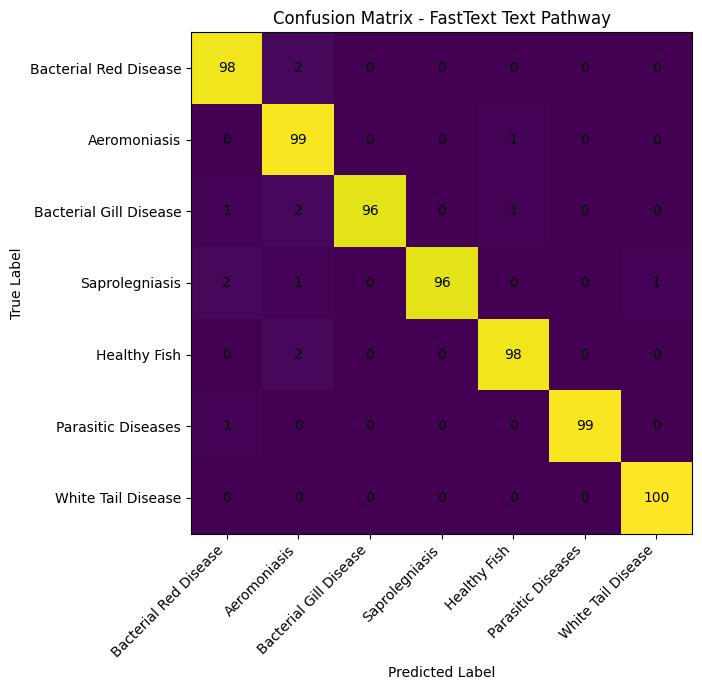

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=DISEASE_CLASSES)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(DISEASE_CLASSES)))
ax.set_yticks(np.arange(len(DISEASE_CLASSES)))
ax.set_xticklabels(DISEASE_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(DISEASE_CLASSES)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - FastText Text Pathway")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
print("===== RANDOM PREDICTION EXAMPLES =====")
sample_examples = test_pred_df.sample(12, random_state=SEED)

for _, row in sample_examples.iterrows():
    print("\nText:", row["text"])
    print("True:", row["true_label"])
    print("Pred:", row["pred_label"])

===== RANDOM PREDICTION EXAMPLES =====

Text: fish looking bad fish gasping and gills not nrmal???
True: Bacterial Gill Disease
Pred: Bacterial Gill Disease

Text: need urgent help there are red spts near fins seems stressed suddenly happened!
True: Bacterial Red Disease
Pred: Bacterial Red Disease

Text: can you check fish opening mouth often and struggling not moving normal many fish affected
True: Bacterial Gill Disease
Pred: Bacterial Gill Disease

Text: PLS HELP FIS RUBBING AGAINST TANK TANK WALL WALL NOT MOVING NORMALL ONE FISH ONLY.
True: Parasitic Diseases
Pred: Parasitic Diseases

Text: NEED NEED URGENT TAIL LOOKS WITE AND DAMAGED PLS SUGGEST..
True: White Tail Disease
Pred: White Tail Disease

Text: what disease is this this no no visible disease signs from.
True: Healthy Fish
Pred: Healthy Fish

Text: please advise white faded and poor swimming from yesterday!
True: White Tail Disease
Pred: White Tail Disease

Text: FISH FLOATING SLOWLY AND NOT FEEDING..
True: Aeromoniasis
P

In [ ]:
all_predictions = []
for _, row in text_df.iterrows():
    pred_label, prob_dict = predict_fasttext_label_and_probs(fasttext_model, row["text"], k=len(DISEASE_CLASSES))

    out_row = {
        "text": row["text"],
        "true_label": row["label"],
        "pred_label": pred_label
    }
    for cls in DISEASE_CLASSES:
        out_row[f"P_text_{cls}"] = prob_dict[cls]
    all_predictions.append(out_row)

p_text_df = pd.DataFrame(all_predictions)
display(p_text_df.head())

,text,true_label,pred_label,P_text_Bacterial Red Disease,P_text_Aeromoniasis,P_text_Bacterial Gill Disease,P_text_Saprolegniasis,P_text_Healthy Fish,P_text_Parasitic Diseases,P_text_White Tail Disease
0,pls help are red spots near fins also slow one...,Bacterial Red Disease,Bacterial Red Disease,1.000008,0.000010,0.000010,0.000011,0.000011,0.000011,0.000010
1,ulcers and reed lesions on body many fish affe...,Bacterial Red Disease,Bacterial Red Disease,0.999867,0.000148,0.000010,0.000015,0.000010,0.000010,0.000010
2,can you check fish fish has rd patches on bood...,Bacterial Red Disease,Bacterial Red Disease,0.995325,0.000022,0.000010,0.004681,0.000010,0.000012,0.000010
3,WHAT DISEASE IS THIS THIS FISH HAS HAS RD PATC...,Bacterial Red Disease,Bacterial Red Disease,0.979547,0.002005,0.000032,0.016084,0.000113,0.001871,0.000418
4,FISSH LOOKING BAD THERE ARE RED FINS PLUS SWIM...,Bacterial Red Disease,Bacterial Red Disease,0.998806,0.000579,0.000011,0.000532,0.000039,0.000089,0.000013


In [ ]:
classification_report_path = OUTPUT_DIR / "fasttext_classification_report.csv"
test_predictions_path = OUTPUT_DIR / "fasttext_test_predictions.csv"
all_predictions_path = OUTPUT_DIR / "p_text_predictions.csv"
synthetic_text_path = OUTPUT_DIR / "synthetic_farmer_symptom_dataset.csv"
metrics_path = OUTPUT_DIR / "fasttext_metrics_summary.csv"

report_df.to_csv(classification_report_path, index=True)
test_pred_df.to_csv(test_predictions_path, index=False)
p_text_df.to_csv(all_predictions_path, index=False)
text_df.to_csv(synthetic_text_path, index=False)

metrics_df = pd.DataFrame({
    "metric": ["test_accuracy", "macro_f1", "weighted_f1"],
    "value": [test_accuracy, macro_f1, weighted_f1]
})
metrics_df.to_csv(metrics_path, index=False)

print("Saved files:")
print(classification_report_path)
print(test_predictions_path)
print(all_predictions_path)
print(synthetic_text_path)
print(metrics_path)
print(model_path)

Saved files:
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_classification_report.csv
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_test_predictions.csv
/content/drive/MyDrive/aquasense/notebook3_outputs/p_text_predictions.csv
/content/drive/MyDrive/aquasense/notebook3_outputs/synthetic_farmer_symptom_dataset.csv
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_metrics_summary.csv
/content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_text_model.bin


In [ ]:
print("===== TEXT PATHWAY RESULTS SUMMARY =====")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Model path: {model_path}")

===== TEXT PATHWAY RESULTS SUMMARY =====
Test Accuracy: 0.9800
Macro F1: 0.9801
Weighted F1: 0.9801
Model path: /content/drive/MyDrive/aquasense/notebook3_outputs/fasttext_text_model.bin


In [ ]:
custom_texts = [
    "fish has cotton like growth on body and looks weak",
    "tail looks white and fish is not swimming normal",
    "fish gasping at surface and gills look bad",
    "fish normal active and eating properly",
    "fish rubbing body on tank wall and seems irritated"
]

for txt in custom_texts:
    pred_label, prob_dict = predict_fasttext_label_and_probs(fasttext_model, txt, k=len(DISEASE_CLASSES))
    print("\nText:", txt)
    print("Predicted label:", pred_label)
    sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 probabilities:", sorted_probs)


Text: fish has cotton like growth on body and looks weak
Predicted label: Saprolegniasis
Top 3 probabilities: [('Saprolegniasis', 1.0000100135803223), ('Bacterial Red Disease', 1.0022774404205848e-05), ('Parasitic Diseases', 1.0000298971135635e-05)]

Text: tail looks white and fish is not swimming normal
Predicted label: White Tail Disease
Top 3 probabilities: [('White Tail Disease', 1.000009298324585), ('Healthy Fish', 1.0692380783439148e-05), ('Saprolegniasis', 1.0034509614342824e-05)]

Text: fish gasping at surface and gills look bad
Predicted label: Bacterial Gill Disease
Top 3 probabilities: [('Bacterial Gill Disease', 1.0000100135803223), ('Parasitic Diseases', 1.0001529517467134e-05), ('White Tail Disease', 1.0000250767916441e-05)]

Text: fish normal active and eating properly
Predicted label: Healthy Fish
Top 3 probabilities: [('Healthy Fish', 1.0000100135803223), ('White Tail Disease', 1.0000050679082051e-05), ('Parasitic Diseases', 1.0000050679082051e-05)]

Text: fish rubbin